# Kidney study — transcript conflict analysis

Each transcript is a semi-structured interview where a participant was shown
**3 pairwise comparisons** (Patient A vs Patient B) and asked which patient
should receive a kidney transplant.

This notebook sends each transcript to Claude and asks it to identify which
of the 3 comparisons showed signs of conflict or difficulty, based purely
on speech patterns.

**Setup:** uses the API key from `../412study/.env`


In [176]:
import sys
!{sys.executable} -m pip install anthropic python-docx python-dotenv --quiet

import anthropic
import pandas as pd
import glob
import os
import docx
from pydantic import BaseModel
from typing import Optional, List
from dotenv import load_dotenv

load_dotenv('../412study/.env')
assert os.environ.get('ANTHROPIC_API_KEY'), 'ANTHROPIC_API_KEY not found — check 412study/.env'
client = anthropic.Anthropic()
print('Client ready.')


Client ready.


In [177]:
class PairwiseDecision(BaseModel):
    comparison_num: int          # 1, 2, or 3
    choice: str                  # 'A', 'B', or 'unclear'
    conflicted: bool             # True if clear signs of difficulty on this comparison
    difficulty_score: int        # 1 (instant) to 5 (prolonged struggle)
    evidence: Optional[str]      # verbatim quote (<30 words) showing conflict, or None

class TranscriptAnalysis(BaseModel):
    decisions: List[PairwiseDecision]

print('Schema defined.')


Schema defined.


In [178]:
SYSTEM_PROMPT = """You are analyzing a verbatim transcript of a research interview about kidney
transplant allocation. During the interview, the participant was shown exactly 3 pairwise
comparisons — each presenting two patients (Patient A and Patient B) who differ on two
features — and asked which patient should receive the kidney.

Your job:
1. Find each of the 3 pairwise comparisons in order. The 1st comparison encountered = 1,
   2nd = 2, 3rd = 3.
2. For each comparison output:
   - comparison_num: 1, 2, or 3
   - choice: 'A', 'B', or 'unclear' (only 'unclear' if genuinely unresolvable)
   - conflicted: true ONLY when there is clear evidence of genuine uncertainty or
     difficulty on THAT specific comparison
   - difficulty_score: 1 (instant, no hesitation) to 5 (prolonged deliberation)
   - evidence: a verbatim quote under 30 words showing the conflict, or null

Signs of conflict/difficulty to look for:
- Explicit statements: 'this is hard', 'tough one', 'I'm torn', 'I'm not sure', 'it's close'
- Self-correction or changing their mind mid-sentence
- Extended back-and-forth before deciding
- Asking for clarification because they cannot decide
- Long hedging before stating a choice ('I think maybe', 'probably', 'I guess')
- Expressing discomfort with having to choose at all

Important: most comparisons will NOT be conflicted. Only mark conflicted=true when the
transcript shows clear evidence of genuine uncertainty on that specific comparison.
difficulty_score should reflect effort on that decision specifically."""

print('System prompt ready.')


System prompt ready.


In [179]:
def extract_docx(path: str) -> str:
    """Extract full text from a .docx file."""
    doc = docx.Document(path)
    return '\n'.join(p.text.strip() for p in doc.paragraphs if p.text.strip())


def analyze_transcript(person_id: str, text: str) -> TranscriptAnalysis:
    """Send transcript to Claude and get structured conflict analysis."""
    response = client.messages.parse(
        model='claude-opus-4-6',
        max_tokens=2000,
        system=[
            {
                'type': 'text',
                'text': SYSTEM_PROMPT,
                'cache_control': {'type': 'ephemeral'},
            }
        ],
        messages=[
            {
                'role': 'user',
                'content': f'Participant ID: {person_id}\n\n{text}'
            }
        ],
        output_format=TranscriptAnalysis,
    )
    return response.parsed_output


print('Functions defined.')


Functions defined.


In [180]:
TRANSCRIPT_CSV = 'kidney_transcript_difficulty.csv'

docx_files = sorted(glob.glob('cleantranscripts/*_clean.docx'))
print(f'Found {len(docx_files)} transcripts.')

if os.path.exists(TRANSCRIPT_CSV):
    print(f'Found {TRANSCRIPT_CSV} — skipping transcript analysis API calls.')
    all_results = None   # sentinel: downstream cells will load from CSV
else:
    all_results = {}
    failed = []

    for path in docx_files:
        person_id = os.path.basename(path).replace('_clean.docx', '')
        print(f'Analyzing {person_id}...', end=' ', flush=True)
        try:
            text     = extract_docx(path)
            analysis = analyze_transcript(person_id, text)
            all_results[person_id] = analysis
            n_conf = sum(1 for d in analysis.decisions if d.conflicted)
            print(f'done. {len(analysis.decisions)} comparisons, {n_conf} conflicted.')
        except Exception as e:
            print(f'FAILED: {e}')
            failed.append(person_id)

    print(f'\nComplete. {len(all_results)} succeeded, {len(failed)} failed.')
    if failed:
        print(f'Failed: {failed}')


Found 20 transcripts.
Found kidney_transcript_difficulty.csv — skipping transcript analysis API calls.


In [181]:
if all_results is None:
    # Load from cached CSV
    df = pd.read_csv(TRANSCRIPT_CSV)
    print(f'Loaded {len(df)} rows from {TRANSCRIPT_CSV}')
else:
    # Flatten from API results
    rows = []
    for person_id, analysis in all_results.items():
        for d in analysis.decisions:
            rows.append({
                'personID':         person_id,
                'comparison':       d.comparison_num,
                'choice':           d.choice,
                'conflicted':       d.conflicted,
                'difficulty_score': d.difficulty_score,
                'evidence':         d.evidence,
            })
    df = pd.DataFrame(rows)

print(df.shape)
df


Loaded 60 rows from kidney_transcript_difficulty.csv
(60, 6)


,personID,comparison,choice,conflicted,difficulty_score,evidence
0,16234,1,B,False,1,"""That one to me is easy. I would go with patie..."
1,16234,2,B,False,2,"""I think I would get with patient B again beca..."
2,16234,3,A,False,2,"""I think I would go with Patient A again, beca..."
3,19857,1,B,True,4,"This one's a tough one, because the one that h..."
4,19857,2,A,False,2,NaN
5,19857,3,A,True,5,Gosh! This one's hard. It keeps getting harder...
6,23405,1,A,True,3,I'm doing mental combat with myself. but I fee...
7,23405,2,A,True,4,"That one's really hard, though."
8,23405,3,B,True,5,one moment I think I would lean towards A and ...
9,25171,1,A,True,4,So. Oof that's so hard when you have those two.


In [182]:
# Summary per person
summary = df.groupby('personID').agg(
    n_comparisons=('comparison', 'count'),
    n_conflicted=('conflicted', 'sum'),
    avg_difficulty=('difficulty_score', 'mean'),
    max_difficulty=('difficulty_score', 'max'),
).assign(pct_conflicted=lambda d: d['n_conflicted'] / d['n_comparisons'] * 100)
print(summary.sort_values('pct_conflicted', ascending=False).round(1).to_string())


          n_comparisons  n_conflicted  avg_difficulty  max_difficulty  pct_conflicted
personID                                                                             
23405                 3             3             4.0               5           100.0
45865                 3             3             4.0               5           100.0
66158                 3             3             3.7               4           100.0
99453                 3             2             3.3               4            66.7
80894                 3             2             3.0               4            66.7
42828                 3             2             3.7               5            66.7
68470                 3             2             3.0               4            66.7
19857                 3             2             3.7               5            66.7
62264                 3             1             3.0               5            33.3
76769                 3             1             1.7 

In [183]:
# Which comparison (1/2/3) is hardest overall?
print('Conflict rate by comparison number:')
print(df.groupby('comparison')['conflicted'].mean().round(3).to_string())
print()

# Show all conflicted decisions with evidence
conflicted = df[df['conflicted']].copy()
print(f'Total conflicted: {len(conflicted)} across {conflicted["personID"].nunique()} persons\n')
for pid in sorted(conflicted['personID'].unique()):
    p = conflicted[conflicted['personID'] == pid]
    print(f'===== {pid} =====')
    for _, row in p.iterrows():
        print(f'  Q{row["comparison"]} [diff={row["difficulty_score"]}] chose {row["choice"]}')
        if row['evidence']:
            print(f'     "{row["evidence"]}"')
    print()


Conflict rate by comparison number:
comparison
1    0.50
2    0.25
3    0.65

Total conflicted: 28 across 17 persons

===== 19857 =====
  Q1 [diff=4] chose B
     "This one's a tough one, because the one that has less years of life has been on the waiting list longer."
  Q3 [diff=5] chose A
     "Gosh! This one's hard. It keeps getting harder. Let me see."

===== 23405 =====
  Q1 [diff=3] chose A
     "I'm doing mental combat with myself. but I feel like I strongly lean towards A"
  Q2 [diff=4] chose A
     "That one's really hard, though."
  Q3 [diff=5] chose B
     "one moment I think I would lean towards A and it's because of the dependent, and that next moment I'm thinking, no, B, because 20 years."

===== 25171 =====
  Q1 [diff=4] chose A
     "So. Oof that's so hard when you have those two."

===== 28789 =====
  Q3 [diff=5] chose B
     ""That one's a lot harder." "That one's tough." "I'm not gonna lie, I guess I went with what when I was in a spot of indecisiveness""

===== 3177

In [184]:
df.to_csv('kidney_transcript_difficulty.csv', index=False)
print('Saved kidney_transcript_difficulty.csv')


Saved kidney_transcript_difficulty.csv


In [185]:
# ─── Cell 10: Feature extraction ─────────────────────────────────────────────
# kidney_features_raw.csv stores absolute A/B feature values for every comparison.
# If it already exists the API calls are skipped entirely.
# The raw CSV is what cells 11 and 14 read from when loading from cache.

from pydantic import BaseModel
from typing import List

class PatientProfile(BaseModel):
    dependents:   int   # number of dependents (e.g. 0, 1, 2, 3)
    life_years:   int   # years of life gained from transplant (e.g. 10, 20, 25)
    obesity:      int   # 0=underweight, 1=normal, 2=overweight, 3=obese, 4=morbidly obese
    work_hours:   int   # expected work hours/week post-transplant
    wait_years:   int   # years on transplant waiting list
    crime:        int   # number of past serious crimes committed (0 if none)

class ComparisonFeatures(BaseModel):
    comparison_num: int
    patient_A: PatientProfile
    patient_B: PatientProfile
    choice: str   # 'A', 'B', or 'unclear'

class TranscriptFeatures(BaseModel):
    comparisons: List[ComparisonFeatures]


EXTRACT_PROMPT = """You are extracting structured feature data from a kidney allocation interview transcript.
The participant was shown exactly 3 pairwise comparisons. The 2nd and 3rd comparisons are
IDENTICAL across every interview — use the values below verbatim for those two:

Comparison 2 (fixed):
  Patient A: dependents=2, life_years=25, obesity=1 (normal weight), work_hours=10, wait_years=5, crime=0
  Patient B: dependents=1, life_years=20, obesity=2 (overweight),    work_hours=30, wait_years=7, crime=0

Comparison 3 (fixed):
  Patient A: dependents=1, life_years=10, obesity=0 (underweight), work_hours=20, wait_years=5, crime=0
  Patient B: dependents=0, life_years=20, obesity=3 (obese),       work_hours=40, wait_years=3, crime=0

Obesity integer codes: 0=underweight, 1=normal/normal weight, 2=overweight, 3=obese, 4=morbidly obese.

For Comparison 1 (which varies per participant), read the transcript to extract the exact
feature values the interviewer describes for Patient A and Patient B.

For ALL THREE comparisons, return COMPLETE feature values for BOTH patients — do NOT leave
any field blank or null, even if two features happen to be equal between the patients.
Also return which patient the participant ultimately chose (choice: 'A' or 'B' or 'unclear').
"""

# Use an absolute path anchored to this notebook's directory so the check and
# save always resolve to the same location regardless of the kernel's CWD.
_NB_DIR = os.path.dirname(os.path.abspath('kidney_transcript_model.ipynb'))
FEATURES_RAW_CSV = os.path.join(_NB_DIR, 'kidney_features_raw.csv')
print(f'Features CSV path : {FEATURES_RAW_CSV}')
print(f'File exists       : {os.path.exists(FEATURES_RAW_CSV)}')

def extract_features(person_id: str, text: str) -> TranscriptFeatures:
    response = client.messages.parse(
        model='claude-opus-4-6',
        max_tokens=2000,
        system=[{'type': 'text', 'text': EXTRACT_PROMPT,
                 'cache_control': {'type': 'ephemeral'}}],
        messages=[{'role': 'user',
                   'content': f'Participant ID: {person_id}\n\n{text}'}],
        output_format=TranscriptFeatures,
    )
    return response.parsed_output


if os.path.exists(FEATURES_RAW_CSV):
    print(f'\nFound {FEATURES_RAW_CSV} — skipping feature extraction API calls.')
    feat_raw_df = pd.read_csv(FEATURES_RAW_CSV)
    all_features = None   # sentinel: downstream cells use feat_raw_df instead
    print(f'Loaded {len(feat_raw_df)} rows ({feat_raw_df["personID"].nunique()} persons).')
else:
    print('\nCSV not found — running feature extraction API calls...')
    all_features = {}
    for path in docx_files:
        person_id = os.path.basename(path).replace('_clean.docx', '')
        print(f'Extracting {person_id}...', end=' ', flush=True)
        try:
            text = extract_docx(path)
            feats = extract_features(person_id, text)
            all_features[person_id] = feats
            for c in feats.comparisons:
                A, B = c.patient_A, c.patient_B
                print(f'\n  Q{c.comparison_num}: '
                      f'A=({A.dependents},{A.life_years},{A.obesity},{A.work_hours},{A.wait_years},{A.crime})'
                      f' B=({B.dependents},{B.life_years},{B.obesity},{B.work_hours},{B.wait_years},{B.crime})'
                      f' →{c.choice}', end='')
            print()
        except Exception as e:
            print(f'FAILED: {e}')

    # Save raw absolute features so future runs skip the API
    raw_rows = []
    for pid, feats in all_features.items():
        for c in feats.comparisons:
            A, B = c.patient_A, c.patient_B
            raw_rows.append({
                'personID': pid, 'comparison': c.comparison_num, 'choice': c.choice,
                'A_dep': A.dependents, 'A_life': A.life_years, 'A_obesity': A.obesity,
                'A_work': A.work_hours, 'A_wait': A.wait_years, 'A_crime': A.crime,
                'B_dep': B.dependents, 'B_life': B.life_years, 'B_obesity': B.obesity,
                'B_work': B.work_hours, 'B_wait': B.wait_years, 'B_crime': B.crime,
            })
    feat_raw_df = pd.DataFrame(raw_rows)
    feat_raw_df.to_csv(FEATURES_RAW_CSV, index=False)
    print(f'\nSaved {FEATURES_RAW_CSV} ({len(feat_raw_df)} rows).')

Features CSV path : /Users/michellesi/Desktop/harvard/topmodel/kidneystudy/kidney_features_raw.csv
File exists       : True

Found /Users/michellesi/Desktop/harvard/topmodel/kidneystudy/kidney_features_raw.csv — skipping feature extraction API calls.
Loaded 60 rows (20 persons).


In [186]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

FEATURES = ['dependents', 'life_years', 'weight_num', 'work_hours', 'wait_years', 'crime_num']

# obesity integer → "distance from normal" for BT sign correction:
#   0=underweight→-1, 1=normal→0, 2=overweight→1, 3=obese→2
def profile_to_vec(p: PatientProfile) -> np.ndarray:
    return np.array([
        float(p.dependents),
        float(p.life_years),
        float(p.obesity - 1),
        float(p.work_hours),
        float(p.wait_years),
        float(p.crime),
    ])


if all_features is None:
    # Reconstruct feat_df from the cached raw-features CSV
    rows = []
    for _, row in feat_raw_df.iterrows():
        y = 1.0 if row['choice'] == 'A' else (0.0 if row['choice'] == 'B' else np.nan)
        if not np.isnan(y):
            rows.append({
                'personID':   row['personID'],
                'comparison': row['comparison'],
                'choice':     row['choice'],
                'y':          y,
                'dx_dependents': row['A_dep']            - row['B_dep'],
                'dx_life_years': row['A_life']           - row['B_life'],
                'dx_weight_num': (row['A_obesity'] - 1)  - (row['B_obesity'] - 1),
                'dx_work_hours': row['A_work']           - row['B_work'],
                'dx_wait_years': row['A_wait']           - row['B_wait'],
                'dx_crime_num':  row['A_crime']          - row['B_crime'],
            })
    feat_df = pd.DataFrame(rows)
    print(f'Reconstructed feat_df from CSV: {len(feat_df)} rows')
else:
    # Build pooled comparison matrix from API results
    rows = []
    for person_id, feats in all_features.items():
        for comp in feats.comparisons:
            vA = profile_to_vec(comp.patient_A)
            vB = profile_to_vec(comp.patient_B)
            dx = vA - vB
            y  = 1.0 if comp.choice == 'A' else (0.0 if comp.choice == 'B' else np.nan)
            if not np.isnan(y):
                rows.append({'personID': person_id,
                             'comparison': comp.comparison_num,
                             'choice': comp.choice, 'y': y,
                             **{f'dx_{f}': dx[i] for i, f in enumerate(FEATURES)}})
    feat_df = pd.DataFrame(rows)

print(f'Pooled comparisons: {len(feat_df)} rows, {feat_df["personID"].nunique()} persons')
print(feat_df[['personID','comparison','choice'] + [f'dx_{f}' for f in FEATURES]].to_string())


Reconstructed feat_df from CSV: 60 rows
Pooled comparisons: 60 rows, 20 persons
    personID  comparison choice  dx_dependents  dx_life_years  dx_weight_num  dx_work_hours  dx_wait_years  dx_crime_num
0      16234           1      B              0             15              0              0             -6             0
1      16234           2      B              1              5             -1            -20             -2             0
2      16234           3      A              1            -10             -3            -20              2             0
3      19857           1      B              0             15              0              0             -6             0
4      19857           2      A              1              5             -1            -20             -2             0
5      19857           3      A              1            -10             -3            -20              2             0
6      23405           1      A             -3              0            

In [187]:
# Sign corrections: higher processed value = higher donation/allocation priority
#   dependents: KEEP  (+1) — more dependents = more people rely on this person
#   life_years: KEEP  (+1) — more years gained = better outcome
#   weight_num: FLIP  (-1) — further from normal = worse health = more urgent
#   work_hours: ambiguous — skip (set SIGN=0 to exclude)
#   wait_years: KEEP  (+1) — longer wait = higher priority
#   crime_num:  FLIP  (-1) — criminal history = lower priority
SIGN = np.array([1., 1., -1., 0., 1., -1.])
active = SIGN != 0
FEAT_ACTIVE = [f for f, a in zip(FEATURES, active) if a]
SIGN_ACTIVE  = SIGN[active]
print(f'Active features ({len(FEAT_ACTIVE)}): {FEAT_ACTIVE}')
print(f'Signs: {dict(zip(FEAT_ACTIVE, SIGN_ACTIVE.astype(int)))}')


def simplex_project(w):
    w_pos = np.clip(w, 0, None)
    total = w_pos.sum()
    return w_pos / total if total > 0 else np.ones(len(w)) / len(w)


def fit_bt(dx, y, reg=1e-2):
    """Fit BT with small L2 regularisation (needed for small N).
    Returns raw weights."""
    K = dx.shape[1]
    def nll(w):
        eta = dx @ w
        loss = float(np.sum(np.logaddexp(0., eta) - y * eta)) + reg * float(np.dot(w, w))
        grad = dx.T @ (expit(eta) - y) + 2 * reg * w
        return loss, grad
    res = minimize(nll, np.zeros(K), jac=True, method='L-BFGS-B',
                   options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-9})
    return res.x


# Build sign-corrected, normalised dx matrix
dx_cols = [f'dx_{f}' for f in FEATURES]
dx_all  = feat_df[dx_cols].values * SIGN          # shape (N, 6), sign-corrected
dx_act  = dx_all[:, active]                        # drop work_hours
y_all   = feat_df['y'].values

# Normalise by max absolute value per feature (use non-nan)
col_max = np.nanmax(np.abs(dx_act), axis=0)
col_max = np.where(col_max > 0, col_max, 1.0)
dx_norm = np.where(np.isnan(dx_act), 0., dx_act / col_max)  # fill nan→0 (feature not varied)

# ── Pooled BT ─────────────────────────────────────────────────────────────────
w_pooled    = fit_bt(dx_norm, y_all)
omega_pooled = simplex_project(w_pooled)
acc_pooled  = ((dx_norm @ w_pooled >= 0) == y_all.astype(bool)).mean()

print('Pooled BT (all persons × all comparisons)')
print(f'  N = {len(y_all)}  acc = {acc_pooled:.1%}')
print(f'  raw w:  {dict(zip(FEAT_ACTIVE, np.round(w_pooled, 3)))}')
print(f'  omega:  {dict(zip(FEAT_ACTIVE, np.round(omega_pooled, 3)))}')

# ── Per-person BT ─────────────────────────────────────────────────────────────
print('\nPer-person BT (3 comparisons each, regularised):')
person_weights = []
header = '  '.join(f'{f[:8]:>9s}' for f in FEAT_ACTIVE)
print(f'{"person":>8}  {"N":>3}  {"acc":>5}  {header}')

for pid in sorted(feat_df['personID'].unique()):
    sub   = feat_df[feat_df['personID'] == pid]
    dx_p  = np.where(np.isnan(dx_act[sub.index]), 0.,
                     dx_act[sub.index] / col_max)
    y_p   = sub['y'].values
    w_p   = fit_bt(dx_p, y_p)
    om_p  = simplex_project(w_p)
    acc_p = ((dx_p @ w_p >= 0) == y_p.astype(bool)).mean()
    om_str = '  '.join(f'{v:9.3f}' for v in om_p)
    print(f'{pid:>8}  {len(y_p):>3}  {acc_p:>5.0%}  {om_str}')
    person_weights.append({'personID': pid, 'acc': acc_p,
                           **{f: om_p[i] for i, f in enumerate(FEAT_ACTIVE)}})

pw_df = pd.DataFrame(person_weights).set_index('personID')


Active features (5): ['dependents', 'life_years', 'weight_num', 'wait_years', 'crime_num']
Signs: {'dependents': 1, 'life_years': 1, 'weight_num': -1, 'wait_years': 1, 'crime_num': -1}
Pooled BT (all persons × all comparisons)
  N = 60  acc = 70.0%
  raw w:  {'dependents': 4.031, 'life_years': 3.095, 'weight_num': -0.475, 'wait_years': 4.574, 'crime_num': 0.0}
  omega:  {'dependents': 0.345, 'life_years': 0.265, 'weight_num': 0.0, 'wait_years': 0.391, 'crime_num': 0.0}

Per-person BT (3 comparisons each, regularised):
  person    N    acc   dependen   life_yea   weight_n   wait_yea   crime_nu
   16234    3   100%      0.000      0.000      0.136      0.864      0.000
   19857    3   100%      0.479      0.000      0.386      0.135      0.000
   23405    3   100%      0.000      0.773      0.169      0.058      0.000
   25171    3   100%      0.389      0.611      0.000      0.000      0.000
   28789    3   100%      0.490      0.192      0.000      0.317      0.000
   31772    3   100%

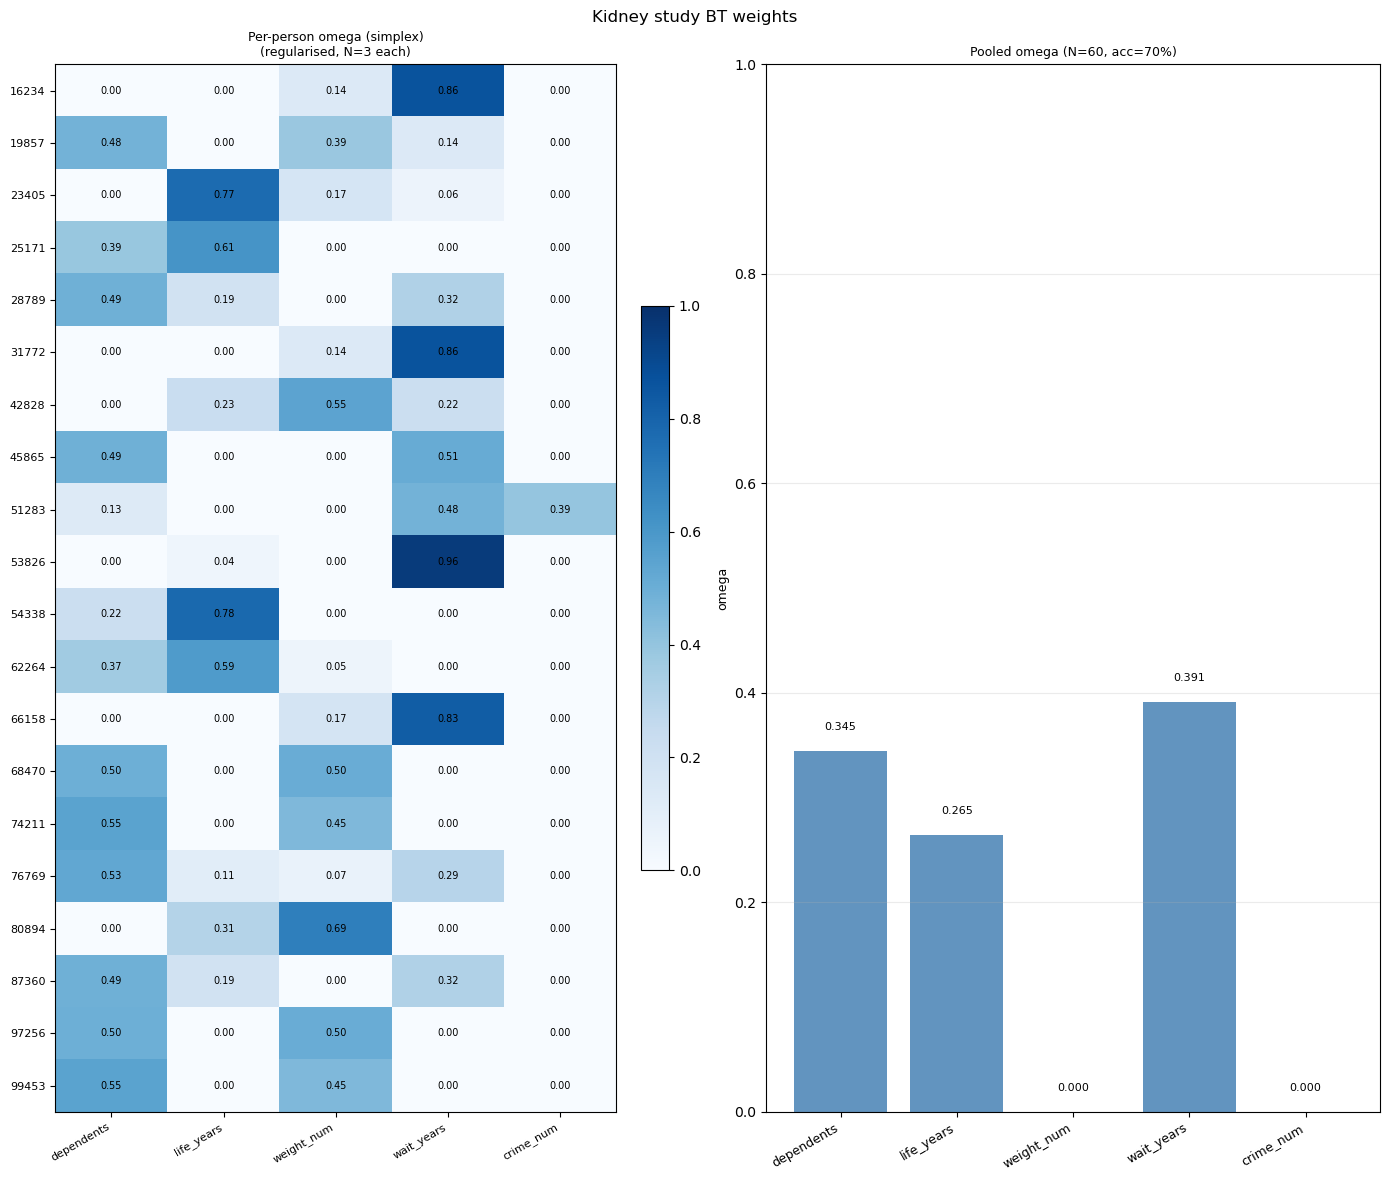

Saved kidney_bt_omega.png


In [188]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 0.45 * len(pw_df) + 3))

# Left: per-person omega heatmap
omega_mat = pw_df[FEAT_ACTIVE].values
ax = axes[0]
im = ax.imshow(omega_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(FEAT_ACTIVE)))
ax.set_xticklabels(FEAT_ACTIVE, fontsize=8, rotation=30, ha='right')
ax.set_yticks(range(len(pw_df)))
ax.set_yticklabels(pw_df.index, fontsize=8)
ax.set_title('Per-person omega (simplex)\n(regularised, N=3 each)', fontsize=9)
for i in range(omega_mat.shape[0]):
    for j in range(omega_mat.shape[1]):
        ax.text(j, i, f'{omega_mat[i,j]:.2f}', ha='center', va='center', fontsize=7)

# Right: pooled omega bar chart
ax2 = axes[1]
colors = ['tomato' if w < 0 else 'steelblue' for w in w_pooled]
ax2.bar(range(len(FEAT_ACTIVE)), omega_pooled, color='steelblue', alpha=0.85)
ax2.set_xticks(range(len(FEAT_ACTIVE)))
ax2.set_xticklabels(FEAT_ACTIVE, fontsize=9, rotation=30, ha='right')
ax2.set_ylim(0, 1)
ax2.set_ylabel('omega', fontsize=9)
ax2.set_title(f'Pooled omega (N={len(y_all)}, acc={acc_pooled:.0%})', fontsize=9)
for i, v in enumerate(omega_pooled):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Kidney study BT weights', fontsize=12)
plt.tight_layout()
plt.savefig('kidney_bt_omega.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved kidney_bt_omega.png')


In [189]:
# ─── Cell 14: Polytope reduction setup ───────────────────────────────────────
# Sign convention (must match BT's SIGN array in cell 12):
#   dependents:   +1  (more dependents = higher priority)
#   life_years:   +1  (more years gained = higher priority)
#   obesity:      -1  → flip in Patient: Patient.obesity = OBESITY_FLIP - raw_obesity
#                      so lower raw obesity → higher Patient value → positive gap when A is less obese ✓
#   work_hours:   0 in BT (excluded); kept in polytope with implicit +1
#   wait_years:   +1  (longer wait = higher priority)
#   crime: excluded from Patient (not in core.py's 5-feature set)
#
# BT applies SIGN in cell 12. Polytope needs the flip baked into Patient objects.

import sys
sys.path.insert(0, '../learning-algo')
from core import (Patient, PairwiseQuery, filter_samples_by_response,
                  sample_from_simplex, resample_from_feasible_set,
                  compute_diameter, FEATURE_NAMES, TAU, TAU_PRIME)
from core import compute_frame_gaps

OBESITY_FLIP  = 5   # Patient.obesity = OBESITY_FLIP - raw_obesity (keeps values in 0-5 range)
LAMBDA_X_STUDY = 2.0  # a 1-unit raw feature diff → gap=2 > tau=1, so every differing dim is active

def raw_to_patient(dep, life, obesity_raw, work, wait) -> Patient:
    """Build a Patient with sign-corrected obesity (lower raw obesity → higher Patient value)."""
    return Patient(
        elderlyDep      = dep,
        lifeYearsGained = life,
        obesity         = OBESITY_FLIP - obesity_raw,   # sign flip
        weeklyWorkhours = work,
        yearsWaiting    = wait,
    )

def profile_to_patient(p: PatientProfile) -> Patient:
    return raw_to_patient(p.dependents, p.life_years, p.obesity, p.work_hours, p.wait_years)

# ── Hardcoded Q2 and Q3 with sign-corrected obesity ───────────────────────────
# Raw Q2: A=(dep=2,life=25,obes=1,work=10,wait=5), B=(dep=1,life=20,obes=2,work=30,wait=7)
# Raw Q3: A=(dep=1,life=10,obes=0,work=20,wait=5), B=(dep=0,life=20,obes=3,work=40,wait=3)
Q2 = PairwiseQuery(
    patient_left  = raw_to_patient(2, 25, 1, 10, 5),   # A
    patient_right = raw_to_patient(1, 20, 2, 30, 7),   # B
)
Q3 = PairwiseQuery(
    patient_left  = raw_to_patient(1, 10, 0, 20, 5),   # A
    patient_right = raw_to_patient(0, 20, 3, 40, 3),   # B
)

def build_q1(pid) -> PairwiseQuery:
    """Build Q1 PairwiseQuery with sign-corrected obesity — from API results or cached CSV.
    Accepts pid as int or str (normalises internally)."""
    pid_str = str(pid)
    if all_features is not None:
        comp = next(c for c in all_features[pid_str].comparisons if c.comparison_num == 1)
        return PairwiseQuery(
            patient_left  = profile_to_patient(comp.patient_A),
            patient_right = profile_to_patient(comp.patient_B),
        )
    else:
        row = feat_raw_df[(feat_raw_df['personID'].astype(str) == pid_str) &
                          (feat_raw_df['comparison'] == 1)].iloc[0]
        return PairwiseQuery(
            patient_left  = raw_to_patient(int(row['A_dep']), int(row['A_life']),
                                           int(row['A_obesity']), int(row['A_work']), int(row['A_wait'])),
            patient_right = raw_to_patient(int(row['B_dep']), int(row['B_life']),
                                           int(row['B_obesity']), int(row['B_work']), int(row['B_wait'])),
        )

def map_response(row) -> str:
    if row['conflicted']:
        return 'incomparable'
    return 'left' if row['choice'] == 'A' else 'right'

# Verify active frames and sign-corrected gaps for Q2 and Q3
print(f'Q2 sign-corrected Patient values:')
print(f'  A={Q2.patient_left}')
print(f'  B={Q2.patient_right}')
g2, af2 = compute_frame_gaps(Q2, lambda_x=LAMBDA_X_STUDY)
print(f'  gaps={dict(zip(FEATURE_NAMES, g2.round(1)))}  active={[FEATURE_NAMES[i] for i in sorted(af2)]}')

print(f'\nQ3 sign-corrected Patient values:')
print(f'  A={Q3.patient_left}')
print(f'  B={Q3.patient_right}')
g3, af3 = compute_frame_gaps(Q3, lambda_x=LAMBDA_X_STUDY)
print(f'  gaps={dict(zip(FEATURE_NAMES, g3.round(1)))}  active={[FEATURE_NAMES[i] for i in sorted(af3)]}')

print(f'\nQ1 per person (sign-corrected):')
for pid in sorted(df['personID'].unique()):
    try:
        q1 = build_q1(pid)
        g1, af1 = compute_frame_gaps(q1, lambda_x=LAMBDA_X_STUDY)
        pA, pB = q1.patient_left, q1.patient_right
        print(f'  {pid}  A=({pA.elderlyDep},{pA.lifeYearsGained},{pA.obesity},{pA.weeklyWorkhours},{pA.yearsWaiting})'
              f'  B=({pB.elderlyDep},{pB.lifeYearsGained},{pB.obesity},{pB.weeklyWorkhours},{pB.yearsWaiting})'
              f'  active={[FEATURE_NAMES[i] for i in sorted(af1)]}')
    except Exception as e:
        print(f'  {pid}: ERROR {e}')

Q2 sign-corrected Patient values:
  A=Patient(elder=2, life=25, obesity=4, work=10, wait=5)
  B=Patient(elder=1, life=20, obesity=3, work=30, wait=7)
  gaps={'elderlyDep': 2.0, 'lifeYearsGained': 10.0, 'obesity': 2.0, 'weeklyWorkhours': -40.0, 'yearsWaiting': -4.0}  active=['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

Q3 sign-corrected Patient values:
  A=Patient(elder=1, life=10, obesity=5, work=20, wait=5)
  B=Patient(elder=0, life=20, obesity=2, work=40, wait=3)
  gaps={'elderlyDep': 2.0, 'lifeYearsGained': -20.0, 'obesity': 6.0, 'weeklyWorkhours': -40.0, 'yearsWaiting': 4.0}  active=['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

Q1 per person (sign-corrected):
  16234  A=(0,25,4,20,1)  B=(0,10,4,20,7)  active=['lifeYearsGained', 'yearsWaiting']
  19857  A=(0,25,4,20,1)  B=(0,10,4,20,7)  active=['lifeYearsGained', 'yearsWaiting']
  23405  A=(0,15,4,20,7)  B=(3,15,4,20,1)  active=['elderlyDep', 'yearsWaiting']
  251

In [199]:
# ─── Cell 20: BALD-notebook algorithms (no active learning) ──────────────────
# Two algorithms for posterior inference over omega ∈ Δ5 (the 5-simplex):
#
#   Pipeline 1 — Multi-Frame Polytope (this work)
#     Data:     all 3 responses, including "incomparable" for conflicted queries
#     Model:    4-tier decision rule with τ=0.25, τ'=0.25, logistic noise
#     Prior:    implicit uniform on simplex
#     Proposal: hit-and-run MCMC
#
#   Pipeline 2 — Standard Bradley-Terry (status quo)
#     Data:     decisive responses only (conflicted queries dropped)
#     Model:    logistic regression P(left) = σ(φᵀω)
#     Prior:    implicit uniform on simplex (NO L2 regularisation)
#     Proposal: same hit-and-run MCMC
#
# Features are normalised to [0,1] so noise scale and thresholds are commensurable.

from scipy.special import expit as _sigmoid

_NDIM      = len(FEATURE_NAMES)   # 5
_TAU       = 0.25
_TAU_PRIME = 0.25
_LAMBDA_X  = 1.0

# ── Feature normalisation ────────────────────────────────────────────────────────
_all = {f: [] for f in FEATURE_NAMES}
for _, row in feat_raw_df.iterrows():
    for pfx in ["A", "B"]:
        _all["elderlyDep"].append(int(row[f"{pfx}_dep"]))
        _all["lifeYearsGained"].append(int(row[f"{pfx}_life"]))
        _all["obesity"].append(OBESITY_FLIP - int(row[f"{pfx}_obesity"]))
        _all["weeklyWorkhours"].append(int(row[f"{pfx}_work"]))
        _all["yearsWaiting"].append(int(row[f"{pfx}_wait"]))

_FEAT_LO = {f: min(v) for f, v in _all.items()}
_FEAT_HI = {f: max(v) for f, v in _all.items()}

print("Feature ranges (sign-corrected):")
for f in FEATURE_NAMES:
    print(f"  {f}: [{_FEAT_LO[f]}, {_FEAT_HI[f]}]")

def _norm(val, lo, hi):
    return (val - lo) / (hi - lo) if hi > lo else 0.5

def _norm_patient(p):
    return Patient(
        elderlyDep      = _norm(p.elderlyDep,      _FEAT_LO["elderlyDep"],      _FEAT_HI["elderlyDep"]),
        lifeYearsGained = _norm(p.lifeYearsGained, _FEAT_LO["lifeYearsGained"], _FEAT_HI["lifeYearsGained"]),
        obesity         = _norm(p.obesity,         _FEAT_LO["obesity"],         _FEAT_HI["obesity"]),
        weeklyWorkhours = _norm(p.weeklyWorkhours, _FEAT_LO["weeklyWorkhours"], _FEAT_HI["weeklyWorkhours"]),
        yearsWaiting    = _norm(p.yearsWaiting,    _FEAT_LO["yearsWaiting"],    _FEAT_HI["yearsWaiting"]),
    )

def _norm_query(q):
    return PairwiseQuery(
        patient_left  = _norm_patient(q.patient_left),
        patient_right = _norm_patient(q.patient_right),
    )

# ── Multi-frame likelihood helpers (Pipeline 1) ───────────────────────────────────
def _frame_gaps_bald(q, lx=_LAMBDA_X):
    diff = q.patient_left.to_array() - q.patient_right.to_array()
    gaps = lx * diff
    active = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active

def _response_probs_mc(q, w, n_mc=100, rng=None):
    """P(resp | q, w) via Monte-Carlo logistic noise; returns [left, right, indiff, incomp]."""
    if rng is None: rng = np.random.default_rng()
    gaps, active = _frame_gaps_bald(q)
    delta = float(np.dot(gaps, w))
    r     = float(sum(w[j] * abs(gaps[j]) for j in active))
    counts = [0, 0, 0, 0]
    for _ in range(n_mc):
        dt = delta + rng.logistic(0, 1.0)
        if   r < _TAU:              counts[2] += 1   # indifferent
        elif abs(dt) < _TAU_PRIME*r: counts[3] += 1  # incomparable
        elif dt >= _TAU_PRIME*r:     counts[0] += 1  # left
        else:                        counts[1] += 1  # right
    return np.array(counts, dtype=float) / n_mc

def _transcript_ll(transcript, w, n_mc=50, rng=None):
    if rng is None: rng = np.random.default_rng()
    idx = {"left": 0, "right": 1, "indifferent": 2, "incomparable": 3}
    ll = 0.0
    for q, resp in transcript:
        probs = _response_probs_mc(q, w, n_mc, rng)
        ll += np.log(max(probs[idx[resp]], 1e-10))
    return ll

# ── Hit-and-run proposal (shared by both pipelines) ──────────────────────────────
def _hit_run_step(x, rng):
    dim = len(x)
    d = rng.standard_normal(dim); d -= d.mean()
    n = np.linalg.norm(d)
    if n < 1e-12: return x.copy()
    d /= n
    t_lo, t_hi = -np.inf, np.inf
    for j in range(dim):
        if   d[j] >  1e-12: t_lo = max(t_lo, -x[j]/d[j])
        elif d[j] < -1e-12: t_hi = min(t_hi, -x[j]/d[j])
    if t_lo >= t_hi - 1e-12: return x.copy()
    nx = x + rng.uniform(t_lo, t_hi) * d
    nx = np.maximum(nx, 0.); nx /= nx.sum()
    return nx

# ── Pipeline 1: Multi-Frame Polytope MCMC ──────────────────────────────────────
def sample_bayes_polytope_posterior(transcript, n_samples=500, burn_in=500,
                                    n_mc=50, rng=None):
    """Hit-and-run MH on simplex with multi-frame MC likelihood. Uniform prior."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    ll = _transcript_ll(transcript, w, n_mc, rng)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _transcript_ll(transcript, wp, n_mc, rng)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Pipeline 2: Bradley-Terry MCMC (uniform prior, no L2) ─────────────────────
def sample_bt_mcmc(phis, ys, n_samples=500, burn_in=500, rng=None):
    """Hit-and-run MH on simplex with BT logistic log-likelihood. Uniform prior (no L2)."""
    if rng is None: rng = np.random.default_rng()
    if len(phis) == 0:
        return rng.dirichlet(np.ones(_NDIM), size=n_samples), 1.0

    def log_likelihood(w):
        lg  = phis @ w
        lp  = np.where(lg>=0, -np.log1p(np.exp(-lg)),   lg - np.log1p(np.exp(lg)))
        lnp = np.where(lg>=0, -lg - np.log1p(np.exp(-lg)), -np.log1p(np.exp(lg)))
        return float(np.sum(ys*lp + (1-ys)*lnp))
        # log-prior = 0 for all w on the simplex (uniform prior)

    w  = np.ones(_NDIM) / _NDIM
    lp = log_likelihood(w)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        lpp = log_likelihood(wp)
        if np.log(max(rng.random(), 1e-15)) < lpp - lp:
            w, lp = wp, lpp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)


# ── Pipeline C: Rao-Kupper (Threshold Bradley-Terry) MCMC ──────────────────
# State: [ω, θ] where ω ∈ Δ5 and θ ∈ (0, 5).
# For query with φ_i = x_A - x_B (normalised) and U_i = φ_iᵀω:
#   P(left)         = σ(U_i - θ)
#   P(right)        = 1 - σ(U_i + θ)
#   P(incomparable) = σ(U_i + θ) - σ(U_i - θ)
# Prior: uniform on simplex for ω; Uniform(0, 5) for θ.
# Proposals: hit-and-run for ω (same as Pipeline A); Gaussian RW for θ.

_THETA_MAX  = 5.0   # upper bound of uniform prior on theta
_THETA_STEP = 0.3   # Gaussian RW step size for theta

def sample_rk_mcmc(phis, responses, n_samples=500, burn_in=500,
                    theta_step=_THETA_STEP, rng=None):
    """
    Hit-and-run + Gaussian RW MH for Rao-Kupper threshold BT.
    phis      : (n, 5) array of normalised feature differences phi = x_A - x_B
    responses : list of 'left', 'right', or 'incomparable' (len = n)
    Returns   : samples (n_samples, 6) where col 5 is theta, acc_w, acc_th
    """
    if rng is None: rng = np.random.default_rng()

    def log_ll(w, th):
        ll = 0.0
        for phi, resp in zip(phis, responses):
            U = float(np.dot(phi, w))
            if resp == 'left':
                p = float(_sigmoid(U - th))
            elif resp == 'right':
                p = 1.0 - float(_sigmoid(U + th))
            else:   # incomparable
                p = float(_sigmoid(U + th)) - float(_sigmoid(U - th))
            ll += np.log(max(p, 1e-10))
        return ll

    w     = np.ones(_NDIM) / _NDIM
    theta = 1.0   # start mid-range
    ll    = log_ll(w, theta)
    samples = []
    n_acc_w = n_acc_th = 0

    for step in range(burn_in + n_samples):
        # --- update omega (hit-and-run, theta fixed) ---
        wp  = _hit_run_step(w, rng)
        llp = log_ll(wp, theta)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc_w += 1

        # --- update theta (reflected Gaussian RW, omega fixed) ---
        theta_p = abs(theta + rng.normal(0, theta_step))  # reflect at 0
        if theta_p < _THETA_MAX:                           # uniform prior on (0, THETA_MAX)
            llp = log_ll(w, theta_p)
            if np.log(max(rng.random(), 1e-15)) < llp - ll:
                theta, ll = theta_p, llp
                if step >= burn_in: n_acc_th += 1

        if step >= burn_in:
            samples.append(np.append(w.copy(), theta))

    samples = np.array(samples)   # shape (n_samples, 6)
    return samples, n_acc_w / max(1, n_samples), n_acc_th / max(1, n_samples)

print("  Pipeline C: sample_rk_mcmc                   (Rao-Kupper threshold BT, uniform prior)")
print("Algorithms ready:")
print("  Pipeline 1: sample_bayes_polytope_posterior  (multi-frame MC likelihood, uniform prior)")
print("  Pipeline 2: sample_bt_mcmc                   (BT logistic likelihood, uniform prior, no L2)")


Feature ranges (sign-corrected):
  elderlyDep: [0, 3]
  lifeYearsGained: [10, 25]
  obesity: [1, 5]
  weeklyWorkhours: [10, 40]
  yearsWaiting: [1, 7]
  Pipeline C: sample_rk_mcmc                   (Rao-Kupper threshold BT, uniform prior)
Algorithms ready:
  Pipeline 1: sample_bayes_polytope_posterior  (multi-frame MC likelihood, uniform prior)
  Pipeline 2: sample_bt_mcmc                   (BT logistic likelihood, uniform prior, no L2)


 tau_prime   mean_acc    mean_var   r vs BT       p
      0.05      0.241     0.07947    -0.108   0.651
      0.10      0.321     0.08221    -0.251   0.286
      0.15      0.392     0.08737    -0.099   0.677
      0.20      0.447     0.09471     0.275   0.241
      0.25      0.490     0.09597     0.108   0.649
      0.35      0.539     0.09473     0.380   0.099
      0.50      0.593     0.09738     0.217   0.357


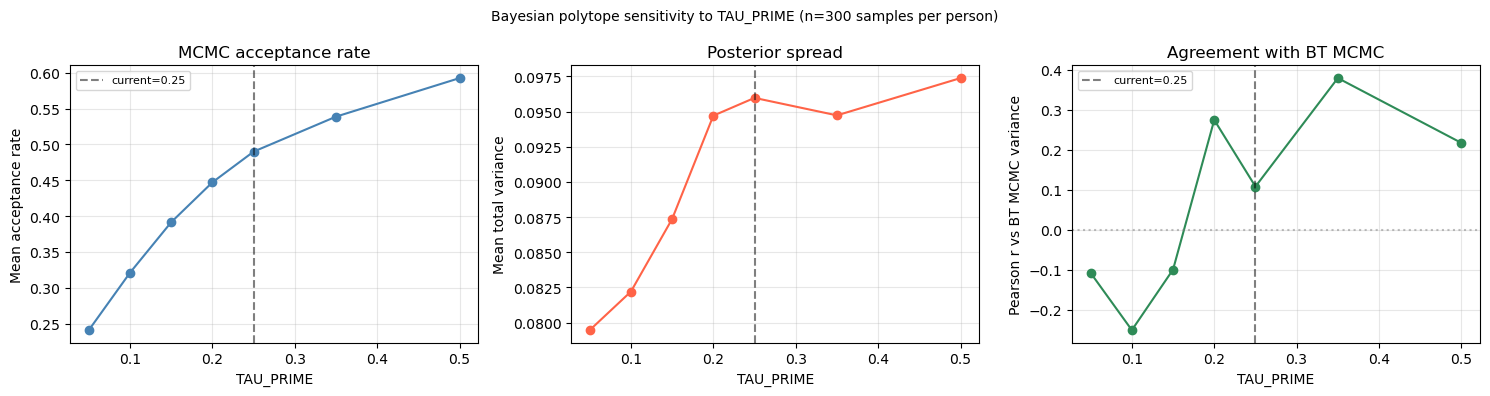

Saved kidney_tau_prime_sweep.png
Best r vs BT MCMC at TAU_PRIME=0.35  (r=0.380)


In [198]:
# ─── Cell 20b: TAU_PRIME sweep — Bayesian polytope sensitivity ────────────────
# Tests TAU_PRIME in [0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50].
# For each value, runs BP MCMC on all persons (small n for speed) and reports:
#   - mean MCMC acceptance rate
#   - mean total posterior variance
#   - Pearson r vs BT MCMC total variance (requires cell 21 to have run first)

from scipy.stats import pearsonr as _pr

_TAU_PRIME_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50]
_N_SWEEP    = 300
_BURN_SWEEP = 200

def _response_probs_mc_tp(q, w, tau_prime, n_mc=50, rng=None):
    """P(resp | q, w) with explicit tau_prime argument."""
    if rng is None: rng = np.random.default_rng()
    gaps, active = _frame_gaps_bald(q)
    delta = float(np.dot(gaps, w))
    r     = float(sum(w[j] * abs(gaps[j]) for j in active))
    counts = [0, 0, 0, 0]
    for _ in range(n_mc):
        dt = delta + rng.logistic(0, 1.0)
        if   r < _TAU:                  counts[2] += 1   # indifferent
        elif abs(dt) < tau_prime * r:   counts[3] += 1   # incomparable
        elif dt >= tau_prime * r:       counts[0] += 1   # left
        else:                           counts[1] += 1   # right
    return np.array(counts, dtype=float) / n_mc

def _transcript_ll_tp(transcript, w, tau_prime, n_mc=30, rng=None):
    if rng is None: rng = np.random.default_rng()
    idx = {"left": 0, "right": 1, "indifferent": 2, "incomparable": 3}
    ll = 0.0
    for q, resp in transcript:
        probs = _response_probs_mc_tp(q, w, tau_prime, n_mc, rng)
        ll += np.log(max(probs[idx[resp]], 1e-10))
    return ll

def sample_bp_tp(transcript, tau_prime, n_samples=_N_SWEEP, burn_in=_BURN_SWEEP, n_mc=30, rng=None):
    """BP MCMC with a specific tau_prime."""
    if rng is None: rng = np.random.default_rng()
    w  = np.ones(_NDIM) / _NDIM
    ll = _transcript_ll_tp(transcript, w, tau_prime, n_mc, rng)
    samples, n_acc = [], 0
    for step in range(burn_in + n_samples):
        wp  = _hit_run_step(w, rng)
        llp = _transcript_ll_tp(transcript, wp, tau_prime, n_mc, rng)
        if np.log(max(rng.random(), 1e-15)) < llp - ll:
            w, ll = wp, llp
            if step >= burn_in: n_acc += 1
        if step >= burn_in: samples.append(w.copy())
    return np.array(samples), n_acc / max(1, n_samples)

# ── Build transcripts once ─────────────────────────────────────────────────────
persons_sorted = sorted(df["personID"].unique(), key=str)
_transcripts = {}
for pid in persons_sorted:
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0: continue
    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try: q1 = build_q1(pid)
    except: continue
    qmap = {1: q1, 2: Q2, 3: Q3}
    _transcripts[pid] = [
        (_norm_query(qmap[int(row["comparison"])]), map_response(row))
        for _, row in person_rows.iterrows()
    ]

# ── Run sweep ────────────────────────────────────────────────────────────────────────
bt_pids  = [p for p in persons_sorted if p in _transcripts and p in bt_bald_results]
bt_v_ref = np.array([bt_bald_results[p]["total_var"] for p in bt_pids])

sweep_results = {}
print("{:>10}  {:>9}  {:>10}  {:>8}  {:>6}".format("tau_prime", "mean_acc", "mean_var", "r vs BT", "p"))

for tp in _TAU_PRIME_VALUES:
    accs, variances = [], []
    rng = np.random.default_rng(42)
    for pid in bt_pids:
        samp, acc = sample_bp_tp(_transcripts[pid], tp, rng=rng)
        accs.append(acc)
        variances.append(samp.var(axis=0).sum())
    bp_v = np.array(variances)
    r, p = _pr(bt_v_ref, bp_v) if len(bt_v_ref) > 2 else (float("nan"), float("nan"))
    sweep_results[tp] = {"mean_acc": np.mean(accs), "mean_var": np.mean(bp_v),
                          "vars": bp_v, "accs": np.array(accs), "persons": bt_pids}
    print("{:>10.2f}  {:>9.3f}  {:>10.5f}  {:>8.3f}  {:>6.3f}".format(tp, np.mean(accs), np.mean(bp_v), r, p))

# ── Plot ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tps   = _TAU_PRIME_VALUES
accs_ = [float(sweep_results[t]["mean_acc"]) for t in tps]
vars_ = [float(sweep_results[t]["mean_var"]) for t in tps]
rs_   = [float(_pr(sweep_results[t]["vars"], bt_v_ref)[0]) for t in tps]
cur   = _TAU_PRIME

axes[0].plot(tps, accs_, "o-", color="steelblue")
axes[0].axvline(cur, color="k", linestyle="--", alpha=0.5, label="current={}".format(cur))
axes[0].set_xlabel("TAU_PRIME"); axes[0].set_ylabel("Mean acceptance rate")
axes[0].set_title("MCMC acceptance rate"); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(tps, vars_, "o-", color="tomato")
axes[1].axvline(cur, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("TAU_PRIME"); axes[1].set_ylabel("Mean total variance")
axes[1].set_title("Posterior spread"); axes[1].grid(True, alpha=0.3)

axes[2].plot(tps, rs_, "o-", color="seagreen")
axes[2].axvline(cur, color="k", linestyle="--", alpha=0.5, label="current={}".format(cur))
axes[2].set_xlabel("TAU_PRIME"); axes[2].set_ylabel("Pearson r vs BT MCMC variance")
axes[2].set_title("Agreement with BT MCMC"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("Bayesian polytope sensitivity to TAU_PRIME (n=300 samples per person)", fontsize=10)
plt.tight_layout()
plt.savefig("kidney_tau_prime_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_tau_prime_sweep.png")
best_tp = tps[int(np.argmax(rs_))]
print("Best r vs BT MCMC at TAU_PRIME={:.2f}  (r={:.3f})".format(best_tp, max(rs_)))


In [192]:
# ─── Cell 21: Run both algorithms per person on the 3 kidney queries ─────────
# Bayesian polytope: hit-and-run MCMC with multi-frame likelihood (all responses)
# BT MCMC:           hit-and-run MCMC with logistic likelihood (left/right only)

N_MCMC   = 500
N_BT_MC  = 500
BURN_IN  = 500

bayes_poly_results = {}
bt_bald_results    = {}

print(f"{'person':>8}  {'bp_acc':>6}  {'bt_acc':>6}  {'bp_var':>8}  {'bt_var':>8}")

for pid in sorted(df["personID"].unique()):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue

    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print(f"{pid:>8}  ERROR: {e}"); continue

    query_map = {1: q1, 2: Q2, 3: Q3}
    rng = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    transcript_all = []
    phis_decisive, ys_decisive = [], []

    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(query_map[comp])
        resp   = map_response(row)
        transcript_all.append((q_norm, resp))
        if resp in ("left", "right"):
            phis_decisive.append(q_norm.patient_left.to_array() - q_norm.patient_right.to_array())
            ys_decisive.append(1.0 if resp == "left" else 0.0)

    phis_arr = np.array(phis_decisive) if phis_decisive else np.zeros((0, _NDIM))
    ys_arr   = np.array(ys_decisive)   if ys_decisive   else np.zeros(0)

    bp_samples, bp_acc = sample_bayes_polytope_posterior(
        transcript_all, n_samples=N_MCMC, burn_in=BURN_IN, n_mc=50, rng=rng
    )
    bayes_poly_results[pid] = {
        "samples":   bp_samples,
        "mean":      bp_samples.mean(axis=0),
        "std":       bp_samples.std(axis=0),
        "total_var": bp_samples.var(axis=0).sum(),
        "acc":       bp_acc,
    }

    bt_samples, bt_acc = sample_bt_mcmc(phis_arr, ys_arr, n_samples=N_BT_MC,
                                         burn_in=BURN_IN, rng=rng)
    bt_bald_results[pid] = {
        "samples":   bt_samples,
        "mean":      bt_samples.mean(axis=0),
        "std":       bt_samples.std(axis=0),
        "total_var": bt_samples.var(axis=0).sum(),
        "acc":       bt_acc,
    }

    print(f"{pid:>8}  {bp_acc:>6.2f}  {bt_acc:>6.2f}"
          f"  {bayes_poly_results[pid]['total_var']:>8.5f}"
          f"  {bt_bald_results[pid]['total_var']:>8.5f}")

print(f"\nDone. {len(bayes_poly_results)} persons.")


  person  bp_acc  bt_acc    bp_var    bt_var
   16234    0.78    0.97   0.11077   0.12580
   19857    0.54    0.99   0.10432   0.12831
   23405    0.44    1.00   0.11228   0.12762
   25171    0.54    0.98   0.08639   0.11465
   28789    0.60    0.98   0.10278   0.13068
   31772    0.64    0.98   0.12734   0.11859
   42828    0.45    0.98   0.12448   0.12095
   45865    0.42    1.00   0.10797   0.13464
   51283    0.55    0.99   0.07286   0.11303
   53826    0.64    0.97   0.10824   0.11370
   54338    0.84    0.95   0.09216   0.11917
   62264    0.62    0.97   0.11900   0.14177
   66158    0.39    1.00   0.10613   0.13316
   68470    0.51    0.99   0.07980   0.13156
   74211    0.57    0.97   0.11188   0.10799
   76769    0.56    0.98   0.08962   0.12224
   80894    0.54    0.99   0.10976   0.13181
   87360    0.65    0.99   0.09634   0.12295
   97256    0.79    0.96   0.11035   0.13804
   99453    0.46    0.99   0.09266   0.12806

Done. 20 persons.


In [193]:
# ─── Cell 21b: BT MCMC — conflicted responses treated as decisive ─────────────
# Same hit-and-run MCMC as cell 21, but includes conflicted responses using the
# participant's reported choice (A/B) as the label rather than dropping them.

bt_decisive_results = {}

for pid in sorted(df["personID"].unique()):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue

    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print(f"{pid:>8}  ERROR: {e}"); continue

    query_map = {1: q1, 2: Q2, 3: Q3}
    rng = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    phis_all, ys_all = [], []
    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(query_map[comp])
        choice = row["choice"]
        if choice not in ("A", "B"): continue
        phis_all.append(q_norm.patient_left.to_array() - q_norm.patient_right.to_array())
        ys_all.append(1.0 if choice == "A" else 0.0)

    phis_arr = np.array(phis_all) if phis_all else np.zeros((0, _NDIM))
    ys_arr   = np.array(ys_all)   if ys_all   else np.zeros(0)

    bt_samples, acc = sample_bt_mcmc(phis_arr, ys_arr, n_samples=N_BT_MC,
                                      burn_in=BURN_IN, rng=rng)
    bt_decisive_results[pid] = {
        "samples":   bt_samples,
        "mean":      bt_samples.mean(axis=0),
        "std":       bt_samples.std(axis=0),
        "total_var": bt_samples.var(axis=0).sum(),
        "acc":       acc,
        "n_obs":     len(phis_all),
    }

print(f"{'person':>8}  {'n_obs':>5}  {'bt_drop_var':>11}  {'bt_decisive_var':>15}  {'bp_var':>8}")
for pid in sorted(bt_decisive_results):
    bv_d = bt_bald_results[pid]["total_var"]    if pid in bt_bald_results    else float("nan")
    bv_c = bt_decisive_results[pid]["total_var"]
    bv_p = bayes_poly_results[pid]["total_var"] if pid in bayes_poly_results else float("nan")
    n    = bt_decisive_results[pid]["n_obs"]
    print(f"{pid:>8}  {n:>5}  {bv_d:>11.5f}  {bv_c:>15.5f}  {bv_p:>8.5f}")

print(f"\nDone. {len(bt_decisive_results)} persons.")


  person  n_obs  bt_drop_var  bt_decisive_var    bp_var
   16234      3      0.12580          0.12668   0.11077
   19857      3      0.12831          0.12039   0.10432
   23405      3      0.12762          0.11403   0.11228
   25171      3      0.11465          0.11728   0.08639
   28789      3      0.13068          0.10973   0.10278
   31772      3      0.11859          0.14272   0.12734
   42828      3      0.12095          0.15243   0.12448
   45865      3      0.13464          0.12882   0.10797
   51283      3      0.11303          0.09835   0.07286
   53826      3      0.11370          0.14876   0.10824
   54338      3      0.11917          0.11468   0.09216
   62264      3      0.14177          0.13384   0.11900
   66158      3      0.13316          0.13652   0.10613
   68470      3      0.13156          0.12131   0.07980
   74211      3      0.10799          0.14293   0.11188
   76769      3      0.12224          0.12336   0.08962
   80894      3      0.13181          0.15498   

BP vs BT-drop:      r=0.216  p=0.360
BP vs BT-decisive:  r=0.679  p=0.001
BT-drop vs BT-dec:  r=0.047  p=0.843


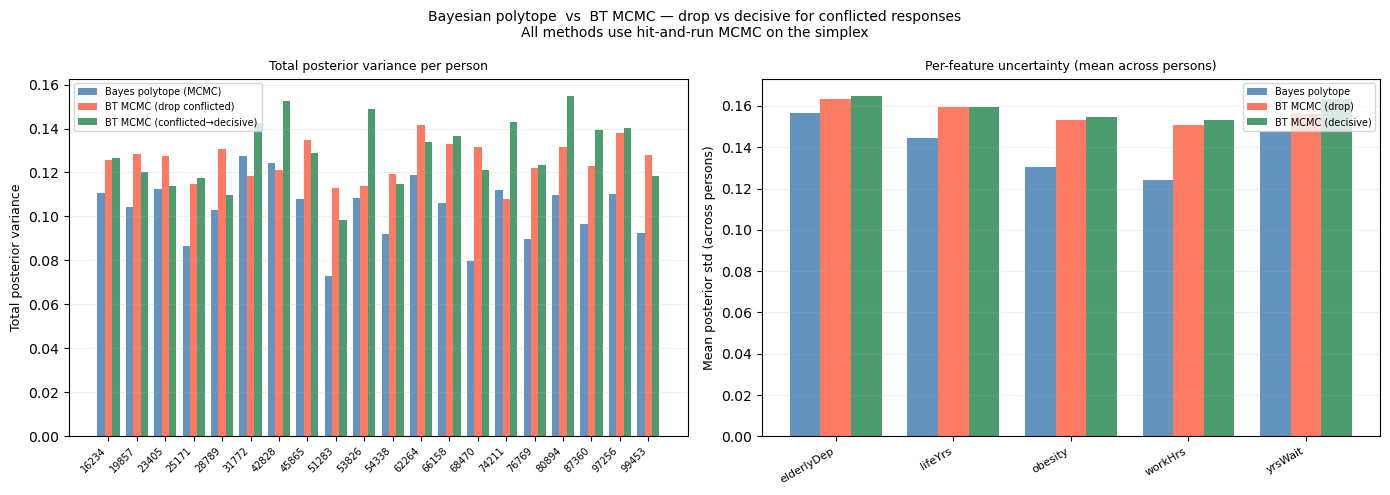

Saved kidney_bayes_poly_vs_bt_bald.png


In [196]:
# ─── Cell 22: Posterior variance — Bayesian polytope vs BT MCMC ──────────────

persons  = sorted(bayes_poly_results.keys())
bp_vars  = np.array([bayes_poly_results[p]["total_var"]   for p in persons])
btd_vars = np.array([bt_bald_results[p]["total_var"]      for p in persons])
btc_vars = np.array([bt_decisive_results[p]["total_var"]  for p in persons])

bp_std   = np.array([bayes_poly_results[p]["std"]         for p in persons])
btd_std  = np.array([bt_bald_results[p]["std"]            for p in persons])
btc_std  = np.array([bt_decisive_results[p]["std"]        for p in persons])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: total variance per person ───────────────────────────────────────────────
ax = axes[0]
x, bw = np.arange(len(persons)), 0.26
ax.bar(x - bw,  bp_vars,  width=bw, color="steelblue", alpha=0.85, label="Bayes polytope (MCMC)")
ax.bar(x,       btd_vars, width=bw, color="tomato",    alpha=0.85, label="BT MCMC (drop conflicted)")
ax.bar(x + bw,  btc_vars, width=bw, color="seagreen",  alpha=0.85, label="BT MCMC (conflicted→decisive)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in persons], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Total posterior variance", fontsize=9)
ax.set_title("Total posterior variance per person", fontsize=9)
ax.legend(fontsize=7); ax.grid(True, alpha=0.2, axis="y")

# ── Right: per-feature std averaged across persons ──────────────────────────
ax3 = axes[1]
feat_labels = ["elderlyDep", "lifeYrs", "obesity", "workHrs", "yrsWait"]
xf, bw3 = np.arange(len(feat_labels)), 0.26
ax3.bar(xf - bw3, bp_std.mean(axis=0),  width=bw3, color="steelblue", alpha=0.85, label="Bayes polytope")
ax3.bar(xf,       btd_std.mean(axis=0), width=bw3, color="tomato",    alpha=0.85, label="BT MCMC (drop)")
ax3.bar(xf + bw3, btc_std.mean(axis=0), width=bw3, color="seagreen",  alpha=0.85, label="BT MCMC (decisive)")
ax3.set_xticks(xf)
ax3.set_xticklabels(feat_labels, rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("Mean posterior std (across persons)", fontsize=9)
ax3.set_title("Per-feature uncertainty (mean across persons)", fontsize=9)
ax3.legend(fontsize=7); ax3.grid(True, alpha=0.2, axis="y")

from scipy.stats import pearsonr
r1, p1 = pearsonr(btd_vars, bp_vars)
r2, p2 = pearsonr(btc_vars, bp_vars)
r3, p3 = pearsonr(btd_vars, btc_vars)
print("BP vs BT-drop:      r={:.3f}  p={:.3f}".format(r1, p1))
print("BP vs BT-decisive:  r={:.3f}  p={:.3f}".format(r2, p2))
print("BT-drop vs BT-dec:  r={:.3f}  p={:.3f}".format(r3, p3))

plt.suptitle(
    "Bayesian polytope  vs  BT MCMC — drop vs decisive for conflicted responses\n"
    "All methods use hit-and-run MCMC on the simplex",
    fontsize=10
)
plt.tight_layout()
plt.savefig("kidney_bayes_poly_vs_bt_bald.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_bayes_poly_vs_bt_bald.png")


  person   bp_acc  rk_accω      bp_var     rk_varω  rk_θ_mean
   16234    0.794    0.960     0.10813     0.12452     0.390
   19857    0.514    0.970     0.11828     0.12378     1.738
   23405    0.408    1.000     0.08177     0.11148     3.836
   25171    0.582    0.982     0.06519     0.12765     0.940
   28789    0.568    0.974     0.09228     0.11709     1.288
   31772    0.570    0.950     0.09506     0.11052     1.125
   42828    0.442    0.968     0.08392     0.13239     1.982
   45865    0.436    1.000     0.10343     0.13845     3.550
   51283    0.548    0.980     0.08393     0.12166     0.922
   53826    0.608    0.960     0.10149     0.12879     0.905
   54338    0.806    0.952     0.11846     0.12367     0.571
   62264    0.636    0.974     0.11535     0.13083     0.943
   66158    0.436    1.000     0.08476     0.12343     4.117
   68470    0.564    0.980     0.12509     0.12877     1.631
   74211    0.582    0.964     0.08788     0.13150     1.014
   76769    0.594    0.

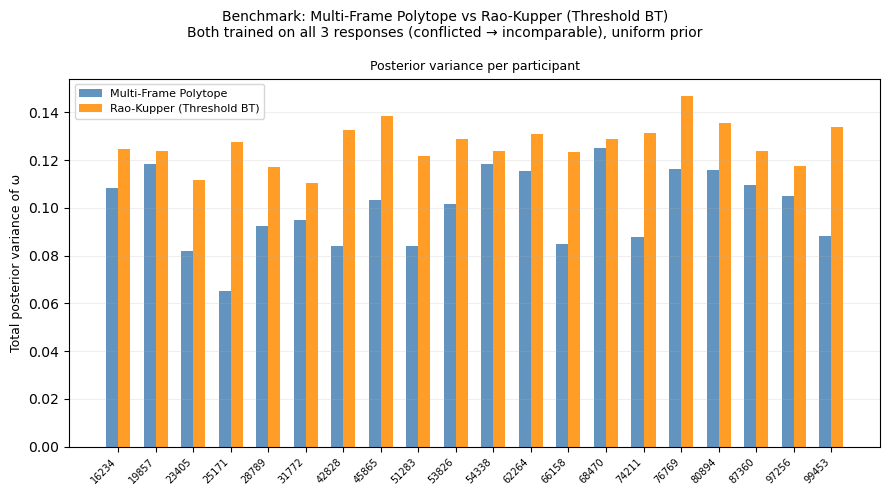

Saved kidney_rk_benchmark.png


In [201]:
# ─── Cell 24: RK Benchmark — Multi-Frame Polytope vs Rao-Kupper ─────────────────
# Both pipelines trained on all 3 responses per participant.
# Pipeline A (Multi-Frame): uses multi-frame MC likelihood, incomparable for conflicted.
# Pipeline C (Rao-Kupper):  uses threshold BT likelihood, incomparable for conflicted.
# Same uninformative priors; variance measured on omega only (not theta).

N_RK = 500
N_RK_BURN = 500

rk_results = {}
bp_rk_results = {}   # re-run BP on same full transcript for clean comparison

print("{:>8}  {:>7}  {:>7}  {:>10}  {:>10}  {:>8}".format(
    "person", "bp_acc", "rk_accω", "bp_var", "rk_varω", "rk_θ_mean"))

for pid in sorted(df["personID"].unique(), key=str):
    pid_str = str(pid)
    if feat_raw_df["personID"].astype(str).eq(pid_str).sum() == 0:
        continue
    person_rows = df[df["personID"] == pid].sort_values("comparison")
    try:
        q1 = build_q1(pid)
    except Exception as e:
        print("{:>8}  ERROR: {}".format(pid, e)); continue

    qmap = {1: q1, 2: Q2, 3: Q3}
    rng  = np.random.default_rng(int(pid_str[-4:]) if pid_str.isdigit() else 0)

    # Build full transcript (all 3 responses)
    transcript_full = []
    phis_rk, responses_rk = [], []
    for _, row in person_rows.iterrows():
        comp   = int(row["comparison"])
        q_norm = _norm_query(qmap[comp])
        resp   = map_response(row)   # left / right / incomparable
        transcript_full.append((q_norm, resp))
        phi = q_norm.patient_left.to_array() - q_norm.patient_right.to_array()
        phis_rk.append(phi)
        responses_rk.append(resp)

    phis_rk_arr = np.array(phis_rk)

    # Pipeline A: Multi-Frame Polytope
    samps_bp, bp_acc = sample_bayes_polytope_posterior(
        transcript_full, n_samples=N_RK, burn_in=N_RK_BURN, n_mc=50,
        rng=np.random.default_rng(rng.integers(1 << 31)))
    bp_var = float(samps_bp.var(axis=0).sum())
    bp_rk_results[pid] = {"samples": samps_bp, "total_var": bp_var, "acc": bp_acc}

    # Pipeline C: Rao-Kupper
    samps_rk, acc_w, acc_th = sample_rk_mcmc(
        phis_rk_arr, responses_rk, n_samples=N_RK, burn_in=N_RK_BURN,
        rng=np.random.default_rng(rng.integers(1 << 31)))
    omega_samps = samps_rk[:, :_NDIM]   # columns 0-4 are omega
    theta_samps = samps_rk[:,  _NDIM]   # column  5  is theta
    rk_var  = float(omega_samps.var(axis=0).sum())
    rk_results[pid] = {
        "samples":    samps_rk,
        "omega_samps": omega_samps,
        "theta_samps": theta_samps,
        "total_var":  rk_var,
        "theta_mean": float(theta_samps.mean()),
        "acc_w":      acc_w,
        "acc_th":     acc_th,
    }

    print("{:>8}  {:>7.3f}  {:>7.3f}  {:>10.5f}  {:>10.5f}  {:>8.3f}".format(
        pid, bp_acc, acc_w, bp_var, rk_var, float(theta_samps.mean())))

# ── Aggregate ────────────────────────────────────────────────────────────────────
persons_rk = sorted(rk_results.keys(), key=str)
bp_vars_rk = np.array([bp_rk_results[p]["total_var"] for p in persons_rk])
rk_vars    = np.array([rk_results[p]["total_var"]    for p in persons_rk])
theta_means = np.array([rk_results[p]["theta_mean"]  for p in persons_rk])

print("\n{}".format("="*52))
print("RK Benchmark  ({} participants)".format(len(persons_rk)))
print("="*52)
print("{:<34} {:>8}  {:>8}".format("Metric", "Multi-Frame", "Rao-Kupper"))
print("-"*52)
print("{:<34} {:>8.5f}  {:>8.5f}".format(
    "Mean total var (omega)", bp_vars_rk.mean(), rk_vars.mean()))
print("{:<34} {:>8.5f}  {:>8.5f}".format(
    "Median total var (omega)", np.median(bp_vars_rk), np.median(rk_vars)))
print("{:<34} {:>8}  {:>8.3f}".format(
    "Mean posterior theta", "N/A", theta_means.mean()))
print("="*52)
print("A wins (bp_var < rk_var): {} / {}".format(
    (bp_vars_rk < rk_vars).sum(), len(persons_rk)))

# ── Plot ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x, bw = np.arange(len(persons_rk)), 0.32
ax.bar(x - bw/2, bp_vars_rk, width=bw, color="steelblue", alpha=0.85, label="Multi-Frame Polytope")
ax.bar(x + bw/2, rk_vars,    width=bw, color="darkorange", alpha=0.85, label="Rao-Kupper (Threshold BT)")
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in persons_rk], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Total posterior variance of ω", fontsize=9)
ax.set_title("Posterior variance per participant", fontsize=9)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis="y")

plt.suptitle(
    "Benchmark: Multi-Frame Polytope vs Rao-Kupper (Threshold BT)\n"
    "Both trained on all 3 responses (conflicted → incomparable), uniform prior",
    fontsize=10)
plt.tight_layout()
plt.savefig("kidney_rk_benchmark.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved kidney_rk_benchmark.png")
